# Spam Classification: CountVectorizer & TF-IDF with Multinomial Naive Bayes, SVM and Logistic Regression

This notebook:
- Loads the cleaned spam dataset
- Uses a **single train/test split** for every comparison
- Fits **CountVectorizer** and **TF-IDF** vectorizers on the training data only, then transforms the test data
- Trains Multinomial Naive Bayes, Linear SVM (LinearSVC), and Logistic Regression on both feature sets.
- Checks each model for **overfitting / underfitting**
- Reports **accuracy, precision, recall, F1** for every combination


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42

## 1. Load the dataset

In [2]:
df = pd.read_csv("../data/cleaned_spam.csv")
df = df.dropna(subset=["clean_message", "label"]).reset_index(drop=True)

X = df["clean_message"].astype(str)
y = df["label"].map({"ham": 0, "spam": 1})

print("Dataset shape:", df.shape)
print("Class distribution:")
print(df["label"].value_counts())
df.head()

Dataset shape: (5167, 3)
Class distribution:
label
ham     4514
spam     653
Name: count, dtype: int64


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


## 2. Train/test split

**This exact split is reused for every model and every feature configuration below**, so all comparisons are apples-to-apples.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y )
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 4133 | Test size: 1034


In [4]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training samples: 4133
Testing samples: 1034

Training distribution:
label
0    87.369949
1    12.630051
Name: proportion, dtype: float64

Testing distribution:
label
0    87.330754
1    12.669246
Name: proportion, dtype: float64


## 3. Feature extraction: CountVectorizer & TF-IDF

Both vectorizers are fit on the training data only and then used to transform the test data, preventing data leakage. CountVectorizer and TfidfVectorizer use their default settings, and each model is trained independently on each feature set for a fair comparison

In [5]:
count_vec = CountVectorizer()

X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

print("---------------CountVectorizer---------------")
print("Training feature shape:", X_train_count.shape)
print("Testing feature shape:", X_test_count.shape)
print("Vocabulary size:", len(count_vec.vocabulary_))


tfidf_vec = TfidfVectorizer()

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print("-------------------TF-IDF---------------")
print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf_vec.vocabulary_))


feature_sets = {
    "CountVectorizer": (X_train_count, X_test_count),
    "TF-IDF": (X_train_tfidf, X_test_tfidf)
}

---------------CountVectorizer---------------
Training feature shape: (4133, 7632)
Testing feature shape: (1034, 7632)
Vocabulary size: 7632
-------------------TF-IDF---------------
Training feature shape: (4133, 7632)
Testing feature shape: (1034, 7632)
Vocabulary size: 7632


## 4. Models

Same `random_state`, same split, same feature config for every run.

In [6]:
def get_models():
    return {
        "MultinomialNB": MultinomialNB(alpha=0.5),
        "LinearSVC": LinearSVC(C=1.0,random_state=RANDOM_STATE, class_weight="balanced", max_iter=5000),
        "LogisticRegression": LogisticRegression(max_iter=1000,random_state=RANDOM_STATE)
    }


## 5. Overfitting / underfitting check function

Compares train accuracy, test accuracy, and 5-fold cross-validation accuracy:

- **Underfitting**: train accuracy itself is low (< 0.85)
- **Overfitting**: train accuracy is high but the train-test gap is large (> 0.05)
- **Good fit**: train accuracy is high and the train-test gap is small


In [7]:
def check_fit(model, X_train, y_train, X_test, y_test):

    train_accuracy = model.score(X_train, y_train)

    test_accuracy = model.score(X_test, y_test)

    gap = train_accuracy - test_accuracy


    print("Train Accuracy:", round(train_accuracy, 4))
    print("Test Accuracy:", round(test_accuracy, 4))
    print("Train-Test Gap:", round(gap, 4))

    if train_accuracy < 0.85:

        print("Status: Underfitting")

    elif gap > 0.05:

        print("Status: Possible Overfitting")

    else:

        print("Status: Good Fit")

In [8]:
trained_models = {}

for feature_name, (X_train_features, X_test_features) in feature_sets.items():

    print("=" * 60)
    print("Feature Set:", feature_name)
    print("=" * 60)

    models = get_models()

    for model_name, model in models.items():

        print("\nModel:", model_name)
        print("-" * 40)

        # Train the model
        model.fit(X_train_features, y_train)

        # Predictions
        y_pred = model.predict(X_test_features)

        # Accuracy
        accuracy = accuracy_score(y_test, y_pred)

        print("Accuracy:", accuracy)

        # Classification Report
        print("\nClassification Report:")

        print(classification_report(y_test,y_pred,target_names=["ham", "spam"]))

        # Model Fit Check
        print("Model Fit Check:")

        check_fit(model,X_train_features,y_train,X_test_features,y_test)

        # Save trained model
        trained_models[(feature_name, model_name)] = model

Feature Set: CountVectorizer

Model: MultinomialNB
----------------------------------------
Accuracy: 0.988394584139265

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.98      0.93      0.95       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034

Model Fit Check:
Train Accuracy: 0.9935
Test Accuracy: 0.9884
Train-Test Gap: 0.0051
Status: Good Fit

Model: LinearSVC
----------------------------------------
Accuracy: 0.9874274661508704

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.99      0.91      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99

Logistic Regression + CountVectorizer Confusion Matrix

[[901   2]
 [ 17 114]]


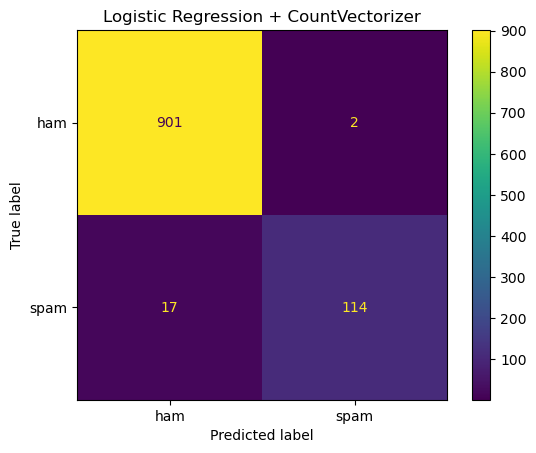

In [9]:
model = trained_models[("CountVectorizer", "LogisticRegression")]
y_pred = model.predict(X_test_count)
cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["ham", "spam"])

disp.plot()
plt.title("Logistic Regression + CountVectorizer")
plt.show()

Save all trained models

In [10]:
import joblib

for (feature_name, model_name), model in trained_models.items():

    file_name = (
        feature_name.replace("-", "_").lower()
        + "_"
        + model_name.lower()
        + ".pkl"
    )

    joblib.dump(model, "../models/" + file_name)

    print(file_name, "saved successfully")

countvectorizer_multinomialnb.pkl saved successfully
countvectorizer_linearsvc.pkl saved successfully
countvectorizer_logisticregression.pkl saved successfully
tf_idf_multinomialnb.pkl saved successfully
tf_idf_linearsvc.pkl saved successfully
tf_idf_logisticregression.pkl saved successfully


Save CountVectorize

In [11]:
joblib.dump(count_vec, "../models/count_vectorizer.pkl")

print("CountVectorizer saved successfully")

CountVectorizer saved successfully


Save TF-IDF Vectorizer

In [12]:
joblib.dump(tfidf_vec, "../models/tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer saved successfully")

TF-IDF Vectorizer saved successfully
